figura guardada

=== Pesos alpha_i ===

Nt = 2
  alpha_s=0: 0.500000, 0.500000
  alpha_s=1: 0.182426, 0.817574
  alpha_s=2: 0.047426, 0.952574
  alpha_s=3: 0.010987, 0.989013

Nt = 3
  alpha_s=0: 0.333333, 0.333333, 0.333333
  alpha_s=1: 0.043896, 0.324352, 0.631752
  alpha_s=2: 0.003806, 0.207815, 0.788379
  alpha_s=3: 0.000295, 0.119168, 0.880537


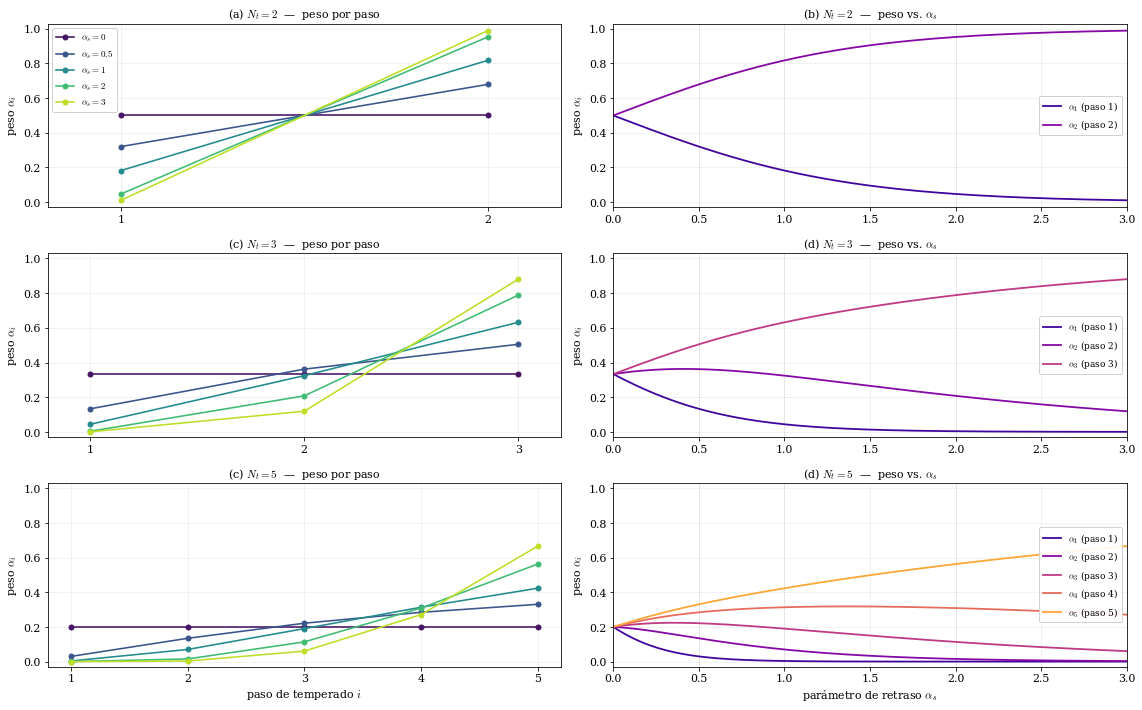

In [9]:
"""
Figura del esquema de temperado (Cap. 2, Metodología).

Panel A: peso alpha_i vs. numero de paso i, una curva por alpha_s (discreto).
Panel B: peso alpha_i vs. alpha_s continuo, una curva por paso i.

Usa exactamente la Ec. del esquema exponencial:
    alpha_i = exp(-(Nt+1) * alpha_s / i) / sum_j exp(-(Nt+1) * alpha_s / j)

Solo Nt = 2 y Nt = 3.
"""
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams["font.family"] = "serif"
rcParams["font.size"] = 11
rcParams["mathtext.fontset"] = "cm"
rcParams["axes.linewidth"] = 0.8


def alpha_weights(Nt, alpha_s):
    """Pesos alpha_i (Ec. del esquema exponencial). alpha_s puede ser array."""
    i = np.arange(1, Nt + 1)
    alpha_s = np.atleast_1d(alpha_s).astype(float)
    # exponentes: forma (len(alpha_s), Nt)
    expo = np.exp(-(Nt + 1) * alpha_s[:, None] / i[None, :])
    w = expo / expo.sum(axis=1, keepdims=True)
    return w  # (len(alpha_s), Nt)


NT_LIST = [2, 3, 5]
ALPHA_S_DISCRETE = [0.0, 0.5, 1.0, 2.0, 3.0]   # curvas en panel A
ALPHA_S_CONT = np.linspace(0, 3, 200)          # eje x continuo en panel B
COLORS = plt.cm.viridis(np.linspace(0.05, 0.9, len(ALPHA_S_DISCRETE)))

fig, axes = plt.subplots(3, 2, figsize=(16, 10))

# ---------------- Panel A: peso vs paso ----------------
for row, Nt in enumerate(NT_LIST):
    ax = axes[row, 0]
    steps = np.arange(1, Nt + 1)
    for c, a_s in zip(COLORS, ALPHA_S_DISCRETE):
        w = alpha_weights(Nt, a_s)[0]
        ax.plot(steps, w, "-o", color=c, ms=5, lw=1.6,
                label=rf"$\alpha_s={a_s:g}$")
    ax.set_xticks(steps)
    ax.set_xlim(0.8, Nt + 0.2)
    ax.set_ylim(-0.03, 1.03)
    ax.set_ylabel(r"peso $\alpha_i$")
    ax.grid(alpha=0.25, lw=0.6)
    panel = "a" if row == 0 else "c"
    ax.set_title(rf"({panel}) $N_t={Nt}$  —  peso por paso", fontsize=11)
    if row == len(NT_LIST) - 1:
        ax.set_xlabel(r"paso de temperado $i$")

# ---------------- Panel B: peso vs alpha_s ----------------
step_colors = plt.cm.plasma(np.linspace(0.1, 0.8, max(NT_LIST)))
for row, Nt in enumerate(NT_LIST):
    ax = axes[row, 1]
    W = alpha_weights(Nt, ALPHA_S_CONT)  # (len(cont), Nt)
    for i in range(Nt):
        ax.plot(ALPHA_S_CONT, W[:, i], color=step_colors[i], lw=1.8,
                label=rf"$\alpha_{{{i+1}}}$ (paso {i+1})")
    # marcar los alpha_s discretos usados
    for a_s in ALPHA_S_DISCRETE:
        ax.axvline(a_s, color="0.75", lw=0.6, ls=":", zorder=0)
    ax.set_xlim(0, 3)
    ax.set_ylim(-0.03, 1.03)
    ax.set_ylabel(r"peso $\alpha_i$")
    ax.grid(alpha=0.25, lw=0.6)
    panel = "b" if row == 0 else "d"
    ax.set_title(rf"({panel}) $N_t={Nt}$  —  peso vs. $\alpha_s$", fontsize=11)
    ax.legend(fontsize=9, loc="center right", framealpha=0.9)
    if row == len(NT_LIST) - 1:
        ax.set_xlabel(r"parámetro de retraso $\alpha_s$")

# leyenda comun del panel A (alpha_s) arriba
handlesA, labelsA = axes[0, 0].get_legend_handles_labels()
axes[0, 0].legend(handlesA, labelsA, fontsize=9, loc="upper left", framealpha=0.9)

fig.tight_layout()
fig.savefig("figures/tempering_schedule.pdf", bbox_inches="tight")
fig.savefig("figures/tempering_schedule.png", dpi=150, bbox_inches="tight")
print("figura guardada")

# imprimir tabla de pesos para verificacion / uso en el texto
print("\n=== Pesos alpha_i ===")
for Nt in [2, 3]:
    print(f"\nNt = {Nt}")
    for a_s in [0, 1, 2, 3]:
        w = alpha_weights(Nt, a_s)[0]
        print(f"  alpha_s={a_s}: " + ", ".join(f"{v:.6f}" for v in w))
plt.show()

In [8]:
import numpy as np
from scipy.optimize import minimize

def alpha_weights(Nt, alpha_s):
    """Pesos alpha_i (Ec. del esquema exponencial). alpha_s puede ser array."""
    i = np.arange(1, Nt + 1)
    alpha_s = np.atleast_1d(alpha_s).astype(float)
    expo = np.exp(-(Nt + 1) * alpha_s[:, None] / i[None, :])
    w = expo / expo.sum(axis=1, keepdims=True)
    return w

# 1. Get the target weights from Nt=5, alpha=1
target_weights = alpha_weights(5, 1.0)[0]
target_last_three = target_weights[-3:] 

# 2. Define a loss function to minimize the difference for Nt=3
def loss(alpha):
    w3 = alpha_weights(3, alpha)[0]
    # Mean Squared Error between the last three elements
    return np.sum((w3[-3:] - target_last_three)**2)

# 3. Find the optimal alpha
result = minimize(loss, x0=1.0)
optimal_alpha = result.x[0]

print(f"Target last three (Nt=5): {target_last_three}")
print(f"Optimal alpha for Nt=3: {optimal_alpha:.4f}")
print(f"Resulting last three (Nt=3): {alpha_weights(3, optimal_alpha)[0][-3:]}")

Target last three (Nt=5): [0.19009754 0.31341786 0.42306986]
Optimal alpha for Nt=3: 0.2808
Resulting last three (Nt=3): [0.20541579 0.36021037 0.43437384]


In [6]:
print( alpha_weights(5, 1.0)[0])
print( alpha_weights(3, 0.25)[0])

[0.00348176 0.06993298 0.19009754 0.31341786 0.42306986]
[0.21755895 0.35869407 0.42374698]
